# Phase 2 - Main experiments (SR-FCA full-scale reproduction of paper Table 2)

Reproduces the MNIST-rotated and MNIST-inverted rows of the paper's Table 2 (test accuracy) and Table 3 (misclustering error) at the **paper's actual configuration**, but on **SR-FCA only**. Comparison values for the four baselines (Local, Global, IFCA, Local-KMeans) are taken verbatim from Table 2 of Vardhan et al. and reported alongside our SR-FCA numbers in the report.

### Setup (paper's MNIST config, §5)

- 1 method: `srfca`
- 2 datasets: `rotated` (angles=`(0, 90, 180, 270)`, K*=4); `inverted` (K*=2)
- 5 seeds: {0, 1, 2, 3, 4}
- m = 100 clients, n = 600 train / 200 test per client, 2-layer MLP (hidden=200)
- Outer rounds T = 280, local epochs E = 2, REFINE rounds R = 2, trim β = 0.1

### Outputs

- `results/main.csv` - one row per (dataset, seed); columns: dataset, seed, test_acc_mean, test_acc_std, misclustering, k_found, wall_sec.
- `results/cache/srfca_{dataset}_seed{seed}_T{T}_R{R}.pkl` - per-run cache so re-runs are cheap. Cache key includes T and R, so changing config does not collide with old caches.
- `results/figures/pairwise_hist_{dataset}.png` - histograms used to pick λ.
- `results/figures/main_bar.png` - SR-FCA-only bar chart, with paper-reported reference lines.

### Structure

1. **Setup** - imports, paths, full-scale config.
2. **λ tuning** - re-fit λ from the pairwise-distance histogram at the new K* values.
3. **Full grid** - SR-FCA × 2 datasets × 5 seeds, resumable via cache.
4. **Aggregation** - summary table and bar chart against paper reference values.


## 1. Setup

In [9]:
from __future__ import annotations

import pickle
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Make `src` importable when running the notebook from `notebooks/`.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import srfca, baselines
from src.datasets import make_mnist_federated
from src.federated import TrainConfig, local_train
from src.models import build_model
from src.metrics import accuracy_hungarian, ari, misclustering_error, nmi
from src.srfca import SRFCAConfig, l2_pairwise, sr_fca
from src.baselines import BaselineConfig, BASELINES
from src.utils import ensure_dir, get_device, set_seed

RESULTS_DIR = ensure_dir(ROOT / "results")
CACHE_DIR = ensure_dir(RESULTS_DIR / "cache")
FIG_DIR = ensure_dir(RESULTS_DIR / "figures")

DEVICE = get_device()
print("device:", DEVICE)

device: cpu


In [10]:
# Shared training config - paper's MNIST setting.
TRAIN_CFG = TrainConfig(lr=0.01, local_epochs=2, batch_size=64, task="classification")

# Full-scale paper config:
M_CLIENTS = 100
N_PER_CLIENT = 600
TEST_PER_CLIENT = 200
ROUNDS = 280            # outer rounds T inside TrimmedMeanGD (paper's value for MNIST)
R_REFINE = 2            # number of REFINE rounds (paper: "at most 2")
BETA = 0.1              # trim fraction
T_MIN = 2               # minimum cluster size
SEEDS = [0, 1, 2, 3, 4]
DATASETS = ["rotated", "inverted"]

# K* = 4 for rotated (paper's 4 cardinal angles); K* = 2 for inverted (identity vs invert).
ANGLES_ROTATED = (0, 90, 180, 270)


## 2. $\lambda$ tuning (pairwise-distance histogram)

The paper picks $\lambda$ from the histogram of pairwise distances between locally-trained client models (Figure 3). For the smoke test on synthetic Gaussians we used $\lambda = 5$; the MLP2 weight space has $\sim 10^5$ dimensions and raw L2 is larger, so that value does not transfer.

Strategy:
1. Train each client locally for one epoch from a shared init.
2. Compute the pairwise L2-distance matrix.
3. Split pairs by ground-truth co-cluster membership; the "valley" between the intra-cluster and inter-cluster modes is a good $\lambda$.

We do this **once per dataset, seed 0 only** - the histogram is qualitatively stable across seeds, and paying one local-train pass here saves a lot of time downstream.

In [11]:
def client_flats_for_dataset(split: str, seed: int = 0):
    """Train each client for one epoch, return (fed, flats)."""
    set_seed(seed)
    kw = dict(angles=ANGLES_ROTATED) if split == "rotated" else {}
    fed = make_mnist_federated(
        split=split, m=M_CLIENTS, n_per_client=N_PER_CLIENT,
        test_per_client=TEST_PER_CLIENT, seed=seed, **kw,
    )
    model = build_model(fed).to(DEVICE)
    init = model.flatten_weights().cpu()
    flats = [local_train(model, c, TRAIN_CFG, DEVICE, init_flat=init) for c in fed.clients]
    return fed, flats

def plot_pairwise_hist(fed, flats, title: str, save_path: Path) -> float:
    """Plot intra- vs inter-cluster pairwise-L2 histograms; return suggested lambda."""
    D = l2_pairwise(flats)
    labels = fed.cluster_labels()
    m = D.shape[0]
    iu, ju = np.triu_indices(m, k=1)
    same = labels[iu] == labels[ju]
    intra = D[iu[same], ju[same]]
    inter = D[iu[~same], ju[~same]]

    fig, ax = plt.subplots(figsize=(6, 3.2))
    bins = np.linspace(D[iu, ju].min(), D[iu, ju].max(), 40)
    ax.hist(intra, bins=bins, alpha=0.6, label=f"intra (n={len(intra)})")
    ax.hist(inter, bins=bins, alpha=0.6, label=f"inter (n={len(inter)})")
    # Midpoint between the 95th pct of intra and 5th pct of inter - robust valley estimate.
    lam = 0.5 * (np.percentile(intra, 95) + np.percentile(inter, 5))
    ax.axvline(lam, color="k", linestyle="--", label=f"$\\lambda$ = {lam:.2f}")
    ax.set_xlabel("pairwise L2 distance on flat weights")
    ax.set_ylabel("count")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=120)
    plt.show()
    return float(lam)


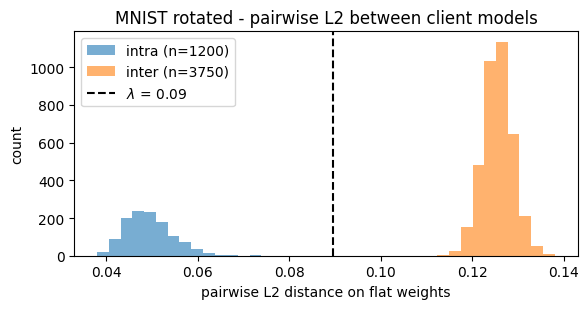

[rotated] lambda = 0.090  (19.1s)


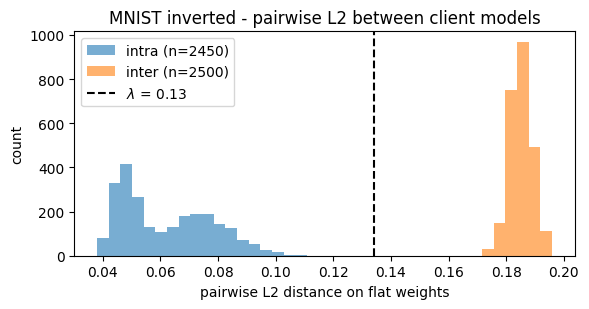

[inverted] lambda = 0.134  (20.0s)


{'rotated': 0.08950641751289368, 'inverted': 0.13423274457454681}

In [12]:
LAMBDAS: dict[str, float] = {}
for split in DATASETS:
    t0 = time.time()
    fed, flats = client_flats_for_dataset(split, seed=0)
    lam = plot_pairwise_hist(
        fed, flats,
        title=f"MNIST {split} - pairwise L2 between client models",
        save_path=FIG_DIR / f"pairwise_hist_{split}.png",
    )
    LAMBDAS[split] = lam
    print(f"[{split}] lambda = {lam:.3f}  ({time.time() - t0:.1f}s)")
LAMBDAS

## 3. Full experiment grid

Each `(method, dataset, seed)` triple is cached after first run as a pickle containing the `Clustering` object, metrics, and wall time. Interrupting and re-running the cell picks up where it stopped.

In [13]:
def evaluate_clustering(fed, clustering) -> dict:
    """Per-client test accuracy + cluster-recovery metric."""
    model = build_model(fed).to(DEVICE)
    accs = []
    for i, client in enumerate(fed.clients):
        c = int(clustering.assignments[i])
        if c < 0 or c not in clustering.cluster_models:
            c = next(iter(clustering.cluster_models))
        model.load_flat_weights(clustering.cluster_models[c].to(DEVICE))
        model.eval()
        with torch.no_grad():
            x = client.x_test.to(DEVICE)
            y = client.y_test.to(DEVICE)
            pred = model(x).argmax(dim=-1)
            accs.append(float((pred == y).float().mean().item()))
    y_true = fed.cluster_labels()
    y_pred = clustering.assignments
    return {
        "test_acc_mean": float(np.mean(accs)),
        "test_acc_std": float(np.std(accs)),
        "misclustering": misclustering_error(y_true, y_pred),
        "k_found": int(clustering.n_clusters()),
    }

def run_one(split: str, seed: int) -> dict:
    """Run one (dataset, seed) cell of the grid, reading/writing the cache.

    Cache key includes T and R so a config change does not collide with
    pre-existing K*=2 / T=10 caches under the same path.
    """
    cache_path = CACHE_DIR / f"srfca_{split}_seed{seed}_T{ROUNDS}_R{R_REFINE}.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    set_seed(seed)
    kw = dict(angles=ANGLES_ROTATED) if split == "rotated" else {}
    fed = make_mnist_federated(
        split=split, m=M_CLIENTS, n_per_client=N_PER_CLIENT,
        test_per_client=TEST_PER_CLIENT, seed=seed, **kw,
    )
    t0 = time.time()
    cfg = SRFCAConfig(
        lambda_=LAMBDAS[split],
        t=T_MIN, beta=BETA, R=R_REFINE, rounds_per_refine=ROUNDS,
        local_train_cfg=TRAIN_CFG, dist_mode="l2",
    )
    clustering = sr_fca(fed, cfg, device=DEVICE, verbose=False)
    wall = time.time() - t0
    metrics = evaluate_clustering(fed, clustering)
    record = {
        "method": "srfca", "dataset": split, "seed": seed,
        "wall_sec": wall, **metrics,
    }
    with open(cache_path, "wb") as f:
        pickle.dump(record, f)
    return record


In [14]:
records = []
for split in DATASETS:
    for seed in SEEDS:
        rec = run_one(split, seed)
        records.append(rec)
        print(
            f"[srfca {split:8s} seed={seed}] "
            f"acc={rec['test_acc_mean']:.3f}  mis={rec['misclustering']:.3f}  "
            f"K={rec['k_found']}  ({rec['wall_sec']/60:.1f} min)"
        )
df = pd.DataFrame.from_records(records)
df.to_csv(RESULTS_DIR / "main.csv", index=False)
df


[srfca rotated  seed=0] acc=0.931  mis=0.000  K=4  (32.4 min)
[srfca rotated  seed=1] acc=0.930  mis=0.000  K=4  (27.7 min)
[srfca rotated  seed=2] acc=0.932  mis=0.000  K=4  (27.8 min)
[srfca rotated  seed=3] acc=0.927  mis=0.000  K=4  (27.9 min)
[srfca rotated  seed=4] acc=0.931  mis=0.000  K=4  (27.6 min)
[srfca inverted seed=0] acc=0.930  mis=0.000  K=2  (27.6 min)
[srfca inverted seed=1] acc=0.929  mis=0.000  K=2  (27.9 min)
[srfca inverted seed=2] acc=0.930  mis=0.000  K=2  (27.9 min)
[srfca inverted seed=3] acc=0.927  mis=0.000  K=2  (27.9 min)
[srfca inverted seed=4] acc=0.932  mis=0.000  K=2  (27.8 min)


,method,dataset,seed,wall_sec,test_acc_mean,test_acc_std,misclustering,k_found
0,srfca,rotated,0,1944.388026,0.93065,0.018797,0.0,4
1,srfca,rotated,1,1663.415523,0.93000,0.019824,0.0,4
2,srfca,rotated,2,1666.942384,0.93185,0.018650,0.0,4
3,srfca,rotated,3,1675.814911,0.92730,0.017527,0.0,4
4,srfca,rotated,4,1653.665758,0.93105,0.017809,0.0,4
5,srfca,inverted,0,1657.671239,0.92970,0.018812,0.0,2
6,srfca,inverted,1,1675.177737,0.92920,0.018231,0.0,2
7,srfca,inverted,2,1671.090801,0.93020,0.019785,0.0,2
8,srfca,inverted,3,1674.155210,0.92665,0.017307,0.0,2
9,srfca,inverted,4,1668.310224,0.93165,0.017875,0.0,2


## 4. Aggregation

In [15]:
summary = (
    df.groupby("dataset")
      .agg(
          acc_mean=("test_acc_mean", "mean"),
          acc_std=("test_acc_mean", "std"),
          mis_mean=("misclustering", "mean"),
          mis_std=("misclustering", "std"),
          k_mean=("k_found", "mean"),
          wall_min_mean=("wall_sec", lambda s: s.mean() / 60),
      )
      .round(3)
)
summary


,acc_mean,acc_std,mis_mean,mis_std,k_mean,wall_min_mean
dataset,,,,,,
inverted,0.929,0.002,0.0,0.0,2.0,27.821
rotated,0.930,0.002,0.0,0.0,4.0,28.681


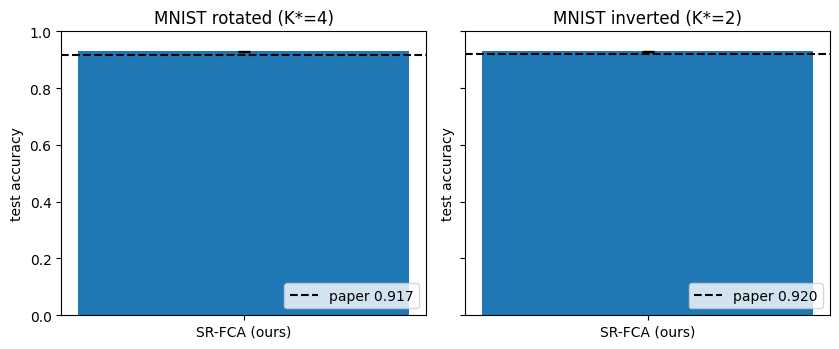

In [16]:
# Paper-reported SR-FCA accuracy (Table 2 of Vardhan et al.)
PAPER_REF = {"rotated": 0.9166, "inverted": 0.9203}

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6), sharey=True)
for ax, split in zip(axes, DATASETS):
    row = summary.loc[split]
    ax.bar(["SR-FCA (ours)"], [row["acc_mean"]], yerr=[row["acc_std"]], capsize=4, color="C0")
    ax.axhline(PAPER_REF[split], color="k", linestyle="--", label=f"paper {PAPER_REF[split]:.3f}")
    ax.set_title(f"MNIST {split} (K*={4 if split == 'rotated' else 2})")
    ax.set_ylabel("test accuracy")
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "main_bar.png", dpi=120)
plt.show()
